In [2]:
from utils import *
from concurrent.futures import ProcessPoolExecutor
import concurrent
from scqubits import Fluxonium
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LogNorm
from tqdm import tqdm  # Import tqdm for the progress bar
%matplotlib inline

In [33]:
def plot(EJ_values,EC,EL,filename):
    def nearby(l,value):
        for item in l:
            if abs(item-value) <= 1e-2:
                return True
        return False

    def get_estimations(EJ):
        # try:
        qubit_level = 25
        qbt = Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
        
        num_evals = 20
        evals = qbt.eigenvals(num_evals)

        transitions_in_interest = [
            evals[3]-evals[0],
            evals[5]-evals[0],
            evals[6]-evals[0]
        ]
        Er_list = np.linspace(transitions_in_interest[0] - 2, transitions_in_interest[-1] + 2, num=1000)
        elements = qbt.matrixelement_table('n_operator',evals_count = num_evals)

        result = []
        for Er in Er_list:
            shifts_from_zero= [get_shift(elements[0,ql2],evals[ql2]-evals[0]-Er) for ql2 in range(num_evals)] 
            shift_from_zero = sum(shifts_from_zero)

            shifts_from_one = [get_shift(elements[1,ql2],evals[ql2]-evals[1]-Er) for ql2 in range(num_evals)] 
            shift_from_one = sum(shifts_from_one)
            shifts_from_two = [get_shift(elements[2,ql2],evals[ql2]-evals[2]-Er) for ql2 in range(num_evals)] 
            shift_from_two = sum(shifts_from_two)

            result.append( 
                        (EJ,
                        Er,
                        abs(shift_from_one-shift_from_two) if not nearby(transitions_in_interest,Er) else np.nan,
                        abs(shift_from_zero-shift_from_two) if not nearby(transitions_in_interest,Er) else np.nan,
                        )
                        )
                    
        return result



    jet = plt.cm.jet

    # Prepare the sweep range for EJ
    
    all_results = []

    # Sweep over EJ values and collect the results with a progress bar
    for n,EJ in enumerate(tqdm(EJ_values, desc="Computing values")):
        results_for_this_EJ = get_estimations(EJ)  # Your function returns a list of tuples
        all_results.extend(results_for_this_EJ)  # Extend the main result list with this sublist


    # Process the results
    EJs, Ers, Z1s, Z2s = zip(*all_results)

    # Binning Y values (assuming Ys are already sorted or the order does not matter)
    num_Er_bins = 200
    Er_min, Er_max = min(Ers), max(Ers)

    Er_bins = np.linspace(Er_min, Er_max, num_Er_bins)
    Er_bin_indices = np.digitize(Ers, Er_bins) - 1  

    # Initialize the Z grids for z1 and z2
    Z1 = np.full((num_Er_bins, len(EJ_values)), np.nan)
    Z2 = np.full((num_Er_bins, len(EJ_values)), np.nan)

    # Populate the Z grids
    for (x, _, z1, z2),Er_bin_idx in zip(all_results,Er_bin_indices):
        EJ_index = np.searchsorted(EJ_values, x)
        Z1[Er_bin_idx, EJ_index] = z1
        Z2[Er_bin_idx, EJ_index] = z2

    # Create masked arrays for NaN values
    Z1m = np.ma.masked_invalid(Z1)
    Z2m = np.ma.masked_invalid(Z2)

    # Plotting the heatmaps with log scale
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Plot Z1 heatmap
    pcm = ax1.imshow(Z1m, extent=(EJ_values[0], EJ_values[-1], Er_bins[0], Er_bins[-1]), origin='lower', aspect='auto', cmap=jet, norm=LogNorm(vmin=1e-5,vmax=1e-3))
    fig.colorbar(pcm, ax=ax1)
    ax1.set_title(f'Difference in shift from qubit state 1 and 2 on oscillator\n over EJ, with qubit 0-3/5/7 transition marked in white')
    ax1.set_xlabel('EJ')
    ax1.set_ylabel('Er')

    # Plot Z2 heatmap
    pcm = ax2.imshow(Z2m, extent=(EJ_values[0], EJ_values[-1], Er_bins[0], Er_bins[-1]), origin='lower', aspect='auto', cmap=jet, norm=LogNorm(vmin=1e-3,vmax=1e-2))
    fig.colorbar(pcm, ax=ax2)
    ax2.set_title(f'Difference in shift from qubit state 1 and 0 on oscillator\n over EJ, with qubit 0-3/5/7 transition marked in white')
    ax2.set_xlabel('EJ')
    ax2.set_ylabel('Er')

    plt.tight_layout()
    plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()
    


Computing values: 100%|██████████| 400/400 [00:26<00:00, 14.92it/s]


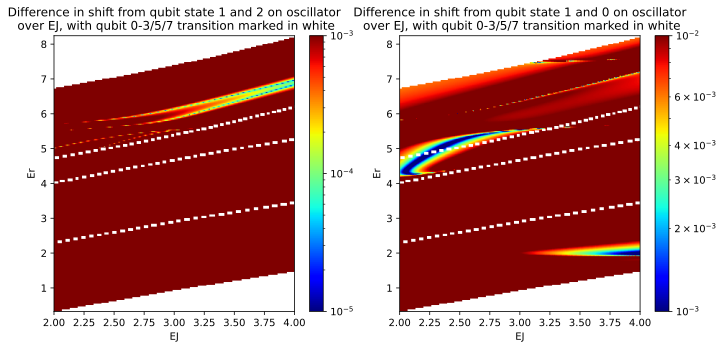

In [32]:

EJ_values = np.linspace(2, 4, 400)
EC = 0.5
EL = 0.1

fig = plot(EJ_values,EC,EL,'sweep_EJ.pdf')

Computing values: 100%|██████████| 400/400 [00:26<00:00, 15.21it/s]


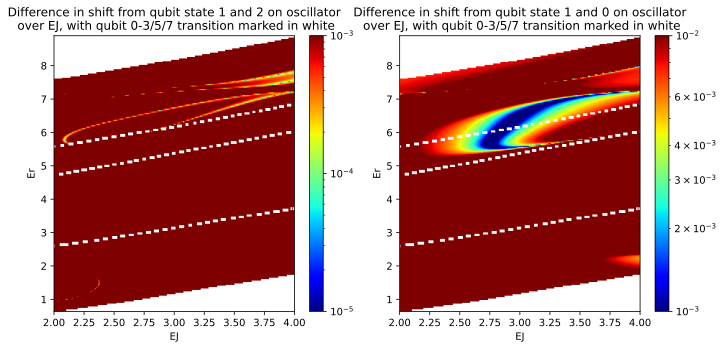

In [35]:

EJ_values = np.linspace(2, 4, 400)
EC = 0.6
EL = 0.13

fig = plot(EJ_values,EC,EL,'sweep_EJ2.pdf')